## TESTING MARGINALS

In [1]:
import autograd.numpy as anp
from autograd import grad
import numpy as np
from scipy import special, integrate
from scipy.stats import t as student_t
import matplotlib.pyplot as plt

import os
os.chdir('..')
os.getcwd()
from sazz.samplers.boomerang_sampler.utils import resample_sticky_pdmp_path
from Filippo_plotting.mcmc_plots import better_pairs


## Spike-and-slab regression

As the sticky Boomerang is specified for models that are sparse, in particular models with spike-and-slab priors, we choose to first consider the marginals of a spike-and-slab linear regression model. Let 
$$
y = \mathbf{X}\theta + \varepsilon
$$
such that $X^{\top}X=nI$ and let 
$$
\theta_j \mid \gamma_j \sim \gamma_j\mathcal{N}(0, \tau^2) + (1-\gamma_j)\delta_0
$$
where $\gamma_j$ is the prior inclusion probability $\mathbb{P}(\theta_i \neq 0)=\gamma_j$. Define the parameter 
$$
\kappa_i = \frac{\gamma_j}{1-\gamma_j}\pi_i(0) = \frac{\gamma_j}{1-\gamma_j}\frac{1}{\sqrt{2\pi \tau^2}}
$$
and the posterior
$$
\pi(\theta_j \mid y) = \tilde{\gamma_j}\mathcal{N}(\theta_j\mid m_j, s_j^2) + (1-\tilde{\gamma_j})\delta_0
$$
with slab parameters
$$
m_j = s_j^2\frac{n}{\sigma^2}\hat{z}_j \qquad s_j^2 = \left(\frac{n}{\sigma^2} + \frac{1}{\tau^2} \right)^{-1}
$$
where $\hat{z}_j=\frac{1}{n}\mathbf{X}^{\top}y$ is the OLS, such that
$$
\frac{\tilde{\gamma_j}}{(1-\tilde{\gamma_j})} = \frac{\gamma_j}{(1-\gamma_j)}\frac{\mathcal{N}(\hat{z}_j\mid, \tau^2+\sigma^2/n)}{\mathcal{N}(\hat{z}_j\mid, \sigma^2/n)}
$$

In [2]:
import autograd.numpy as anp
from autograd import grad
import numpy as np
from scipy.stats import norm

# ============================================================
# Data generation
# ============================================================
def generate_spike_slab_data(n=200, d=20, d_nonzero=5, sigma=1.0, tau=2.0, seed=42):
    rng = np.random.default_rng(seed)

    # Orthogonal design: X such that X^T X = nI
    # Take first d columns of a random orthogonal matrix, scaled by sqrt(n)
    Q, _ = np.linalg.qr(rng.normal(size=(n, n)))
    X = Q[:, :d] * np.sqrt(n)

    # True theta: first d_nonzero are nonzero
    theta_true = np.zeros(d)
    theta_true[:d_nonzero] = rng.normal(loc=0, scale=tau, size=d_nonzero)

    # Observations
    y = X @ theta_true + rng.normal(scale=sigma, size=n)

    # OLS estimates
    z_hat = X.T @ y / n

    return X, y, theta_true, z_hat

# ============================================================
# Target and gradient
# ============================================================
def nll_spike_slab(z_hat, n, sigma, tau):
    """
    Energy for the continuous (slab) part of the posterior.
    E(theta) = sum_j  n/(2*sigma^2) * (z_hat_j - theta_j)^2 + 1/(2*tau^2) * theta_j^2
    """
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    def E(theta):
        return anp.sum(
            0.5 * eta_lik * (z_hat - theta)**2
            + 0.5 * eta_prior * theta**2
        )

    return E


def grad_spike_slab(z_hat, n, sigma, tau):
    """
    Gradient: nabla_j E = (n/sigma^2 + 1/tau^2) * theta_j - (n/sigma^2) * z_hat_j
    """
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    def gradE(theta):
        return (eta_lik + eta_prior) * theta - eta_lik * z_hat

    return gradE

# ============================================================
# Posterior quantities (closed form)
# ============================================================
def posterior_spike_slab_params(z_hat, n, sigma, tau, gamma_prior):
    """
    Returns posterior inclusion probabilities and slab parameters.
    """
    d = len(z_hat)
    eta_lik = n / sigma**2
    eta_prior = 1.0 / tau**2

    # Slab posterior parameters
    s2 = 1.0 / (eta_lik + eta_prior)
    m = s2 * eta_lik * z_hat

    # Posterior inclusion: gamma_post / (1 - gamma_post)
    #   = gamma / (1 - gamma) * N(z_hat; 0, tau^2 + sigma^2/n) / N(z_hat; 0, sigma^2/n)
    var_slab = tau**2 + sigma**2 / n
    var_spike = sigma**2 / n

    log_bf = (norm.logpdf(z_hat, 0, np.sqrt(var_slab))
              - norm.logpdf(z_hat, 0, np.sqrt(var_spike)))

    log_prior_odds = np.log(gamma_prior / (1 - gamma_prior))
    log_post_odds = log_prior_odds + log_bf

    gamma_post = 1.0 / (1.0 + np.exp(-log_post_odds))

    return m, s2, gamma_post

# ============================================================
# Analytical marginal density
# ============================================================
def marginal_pdf_spike_slab(theta_grid, m_j, s2_j, gamma_post_j):
    """
    Marginal posterior density for coordinate j.
    Continuous part: gamma_post * N(theta | m_j, s2_j)
    Point mass: (1 - gamma_post) * delta_0
    
    For histogram comparison, we only plot the continuous part,
    and separately check the fraction of samples at exactly zero.
    """
    return gamma_post_j * norm.pdf(theta_grid, m_j, np.sqrt(s2_j))

# ============================================================
# Setup
# ============================================================
n, d, d_nonzero = 200, 5, 3
sigma = 1.0
tau = 2.0
gamma_prior = 0.5  # prior inclusion probability

X, y, theta_true, z_hat = generate_spike_slab_data(
    n=n, d=d, d_nonzero=d_nonzero, sigma=sigma, tau=tau
)

# Target and gradient
E_ss = nll_spike_slab(z_hat, n, sigma, tau)
gradE_ss = grad_spike_slab(z_hat, n, sigma, tau)

# Posterior quantities
m, s2, gamma_post = posterior_spike_slab_params(z_hat, n, sigma, tau, gamma_prior)

# Kappa (prior value, fixed)
kappa = (gamma_prior / (1 - gamma_prior)) / np.sqrt(2 * np.pi * tau**2)

print("True theta:", theta_true)
print("OLS estimates:", z_hat)
print("Posterior means (slab):", m)
print("Posterior s^2:", s2)
print("Posterior inclusion prob:", gamma_post)
print("Kappa (prior, fixed):", kappa)
    

True theta: [-1.79953635 -2.51634498  0.66523259  0.          0.        ]
OLS estimates: [-1.74334076e+00 -2.53502090e+00  6.50417170e-01 -1.08201242e-01
  2.43017494e-03]
Posterior means (slab): [-1.74116431e+00 -2.53185608e+00  6.49605164e-01 -1.08066160e-01
  2.42714101e-03]
Posterior s^2: 0.004993757802746567
Posterior inclusion prob: [1.         1.         1.         0.10214262 0.03414688]
Kappa (prior, fixed): 0.19947114020071635


In [3]:
import os
os.chdir('..')
os.getcwd()
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler import StickyBoomerangSampler
from sazz.samplers.boomerang_sampler.StickyBoomerangSampler_pli import StickyBoomerangSampler_pli

N=5000

sampler = StickyBoomerangSampler(
    E=E_ss, N=N, D=d,
    grad_target=gradE_ss, kappa=kappa,
)
sampler.preprocess(method="diagonal")

sampler_pli = StickyBoomerangSampler_pli(
    E=E_ss, N=N, D=d,
    grad_target=gradE_ss, kappa=kappa,
)
sampler_pli.preprocess(method="diagonal")

In [4]:
sampler.sample_auto()

Sticky Boomerang time: 100%|█████████▉| 4999/5000 [00:11<00:00, 436.00iter/s, time=33206.652]


=== Sampler Diagnostics ===
Total gradient evals: 999612
Grad evals per skeleton point: 199.9
Mean sparsity (fraction frozen): 0.372
Max simultaneous frozen: 4 / 5

=== Thinning Diagnostics ===
Rate evals per Brent call: 25.6 mean, 47 max
Accept/Reject: 0/0

=== Event-type breakdown ===
  freeze    :   865 events, mean horizon=0.3987
  thaw      :   863 events, mean horizon=0.4754
  refresh   :  3271 events, mean horizon=0.0000

=== Timing ===
Mean wall-seconds per iteration: 0.000287
Total wall-seconds: 11.24

Time passed: 33206.65157374621


In [5]:
sampler_pli.sample_auto()

Sticky Boomerang PLI time: 100%|█████████▉| 4999/5000 [00:00<00:00, 15900.08iter/s, time=33344.553]


=== Sampler Diagnostics ===
Total gradient evals: 9998
Grad evals per skeleton point: 2.0
Mean sparsity (fraction frozen): 0.352
Max simultaneous frozen: 4 / 5

=== Thinning Diagnostics (PLI) ===
Bound violations: 0 across 0 calls
Max ratio: 0.0000
Rate evals per call: 1.4 mean, 2 max
Proposals per call: 0.0 mean, 0 max
Accepted bounces: 0

=== Event-type breakdown ===
  freeze    :   862 events, mean horizon=2.5299
  thaw      :   861 events, mean horizon=7.2916
  refresh   :  3276 events, mean horizon=0.0000

=== Timing ===
Mean wall-seconds per iteration: 0.000044
Total wall-seconds: 0.50

Time passed: 33344.553006689224


In [12]:
t, x = resample_sticky_pdmp_path(sampler, n_samples=50000)
t_pli, x_pli = resample_sticky_pdmp_path(sampler_pli, n_samples=50000)

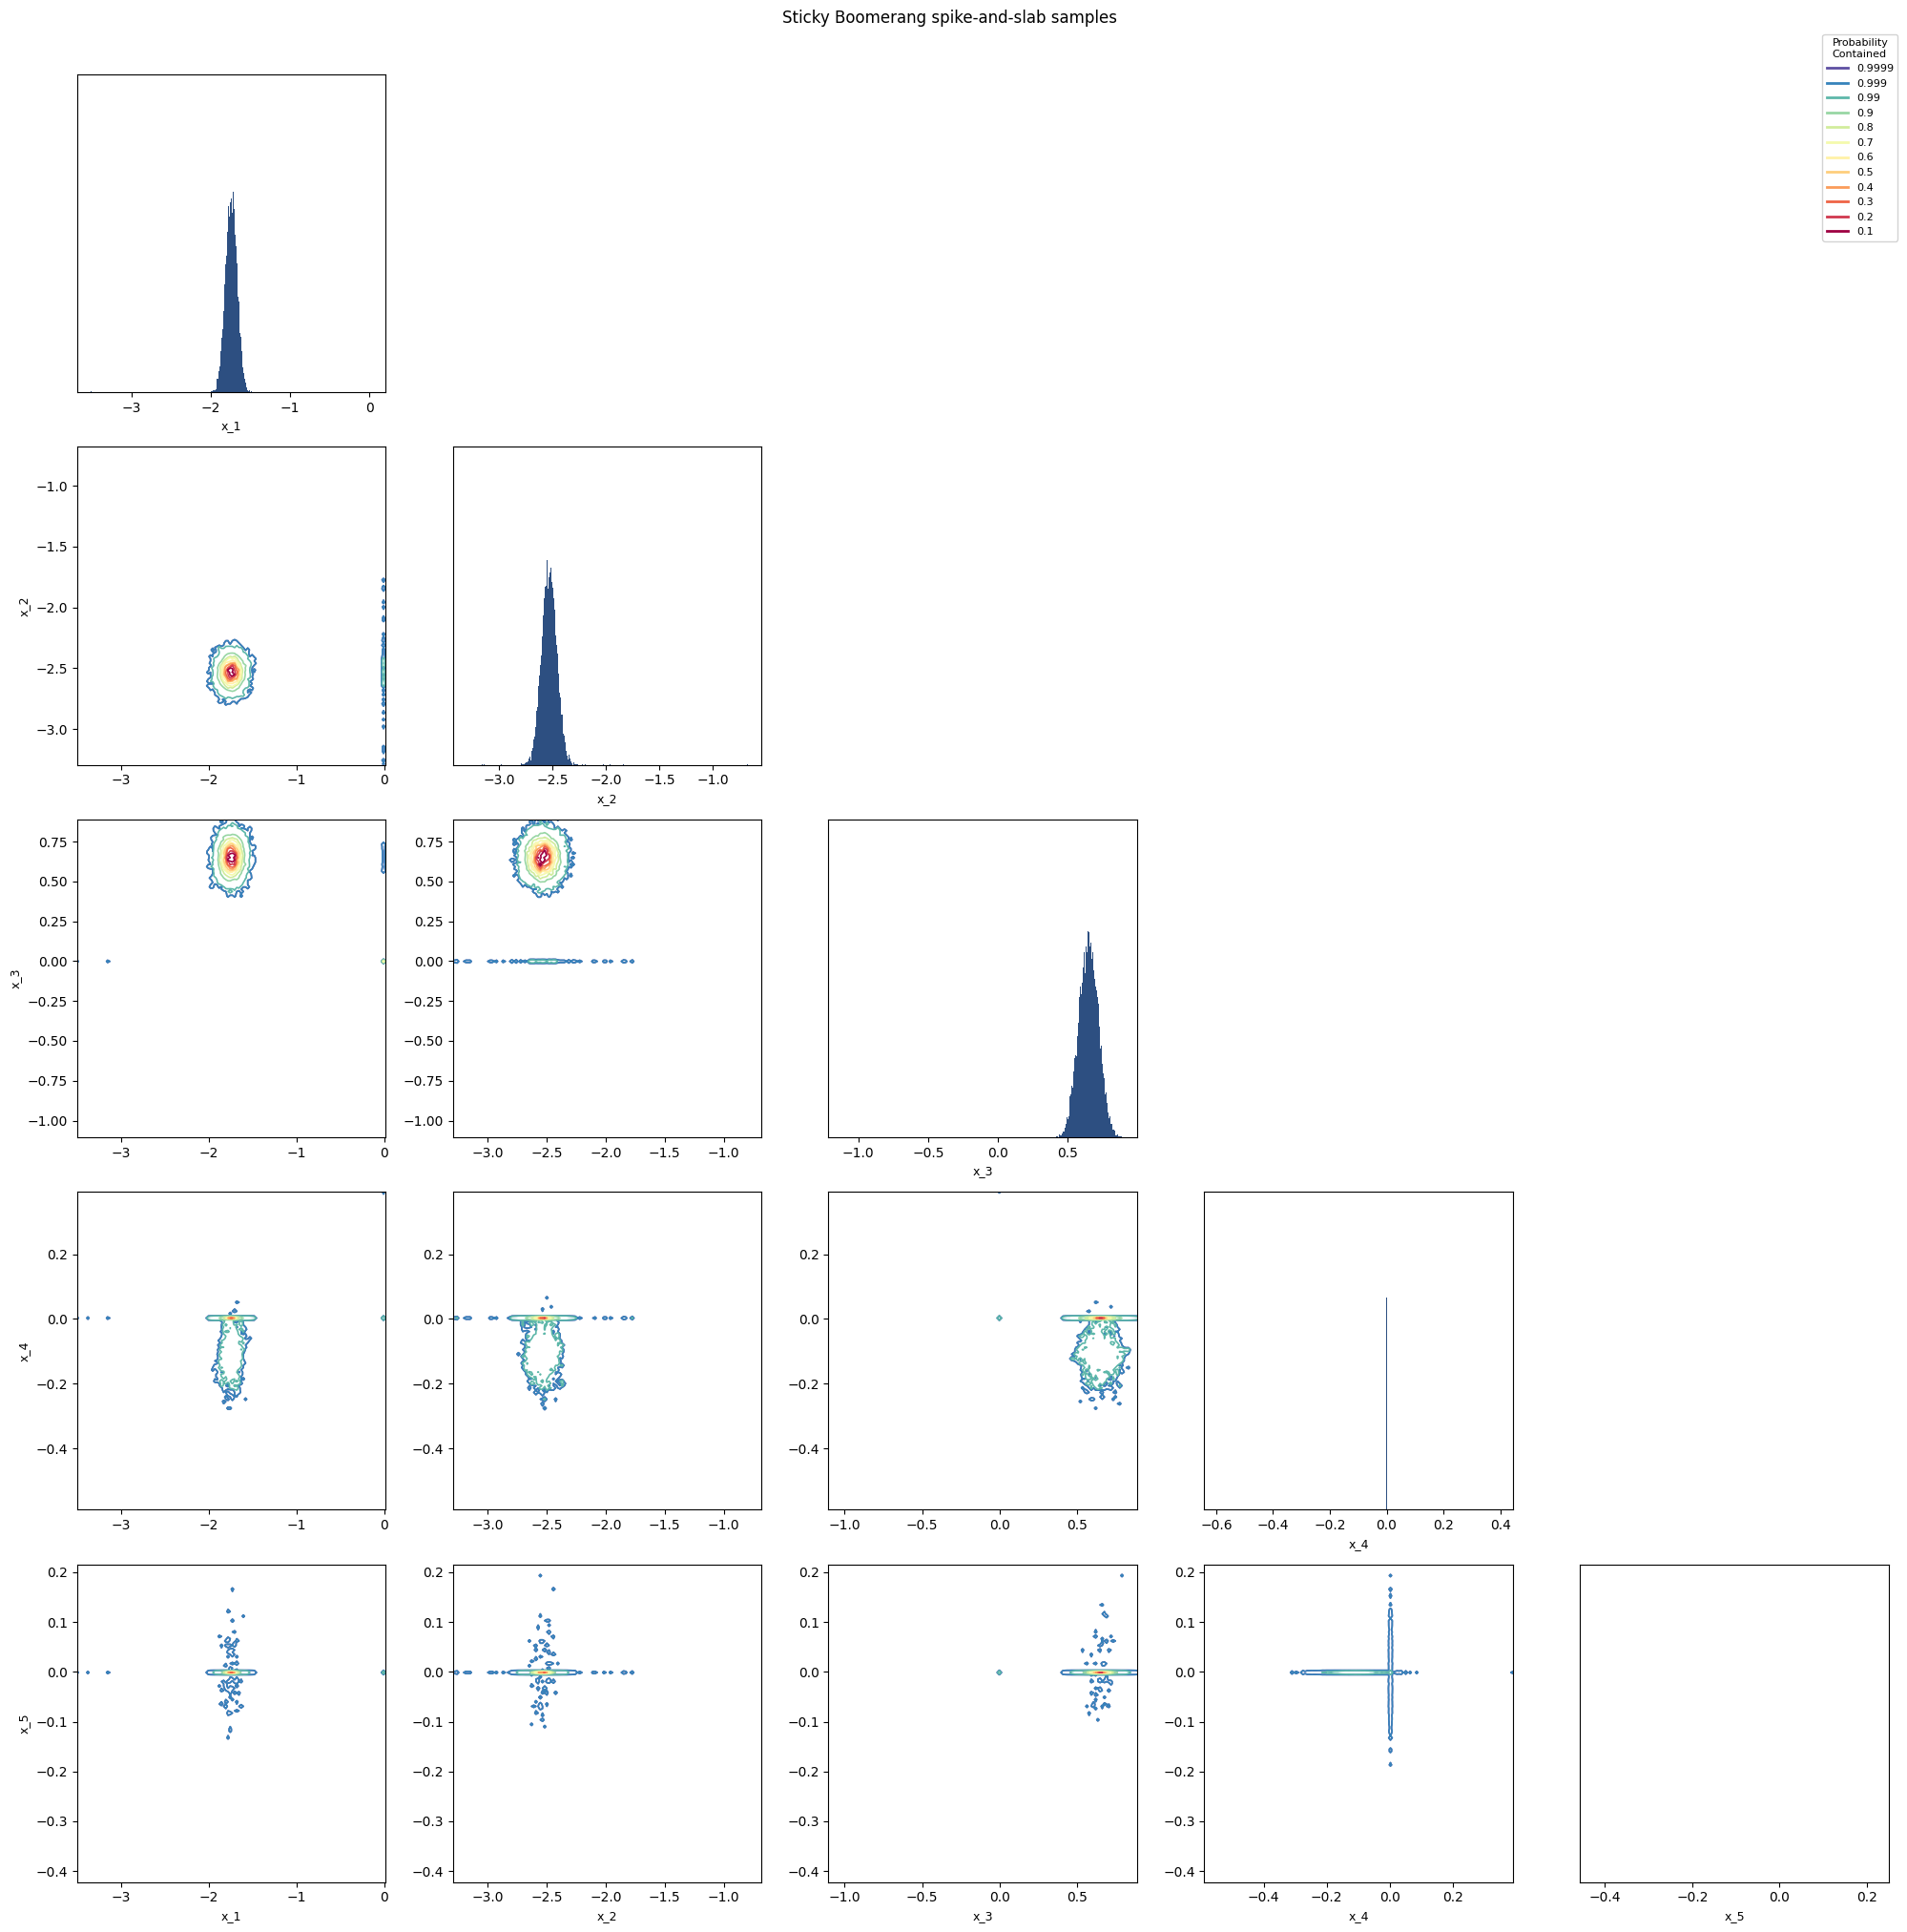

In [13]:
# ── Plug in your own samples here ─────────────────────────────────────────────
variable_names_ss = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']   # optional

fig, axes = better_pairs(
    x,
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_ss,
    title='Sticky Boomerang spike-and-slab samples',
)
plt.show()

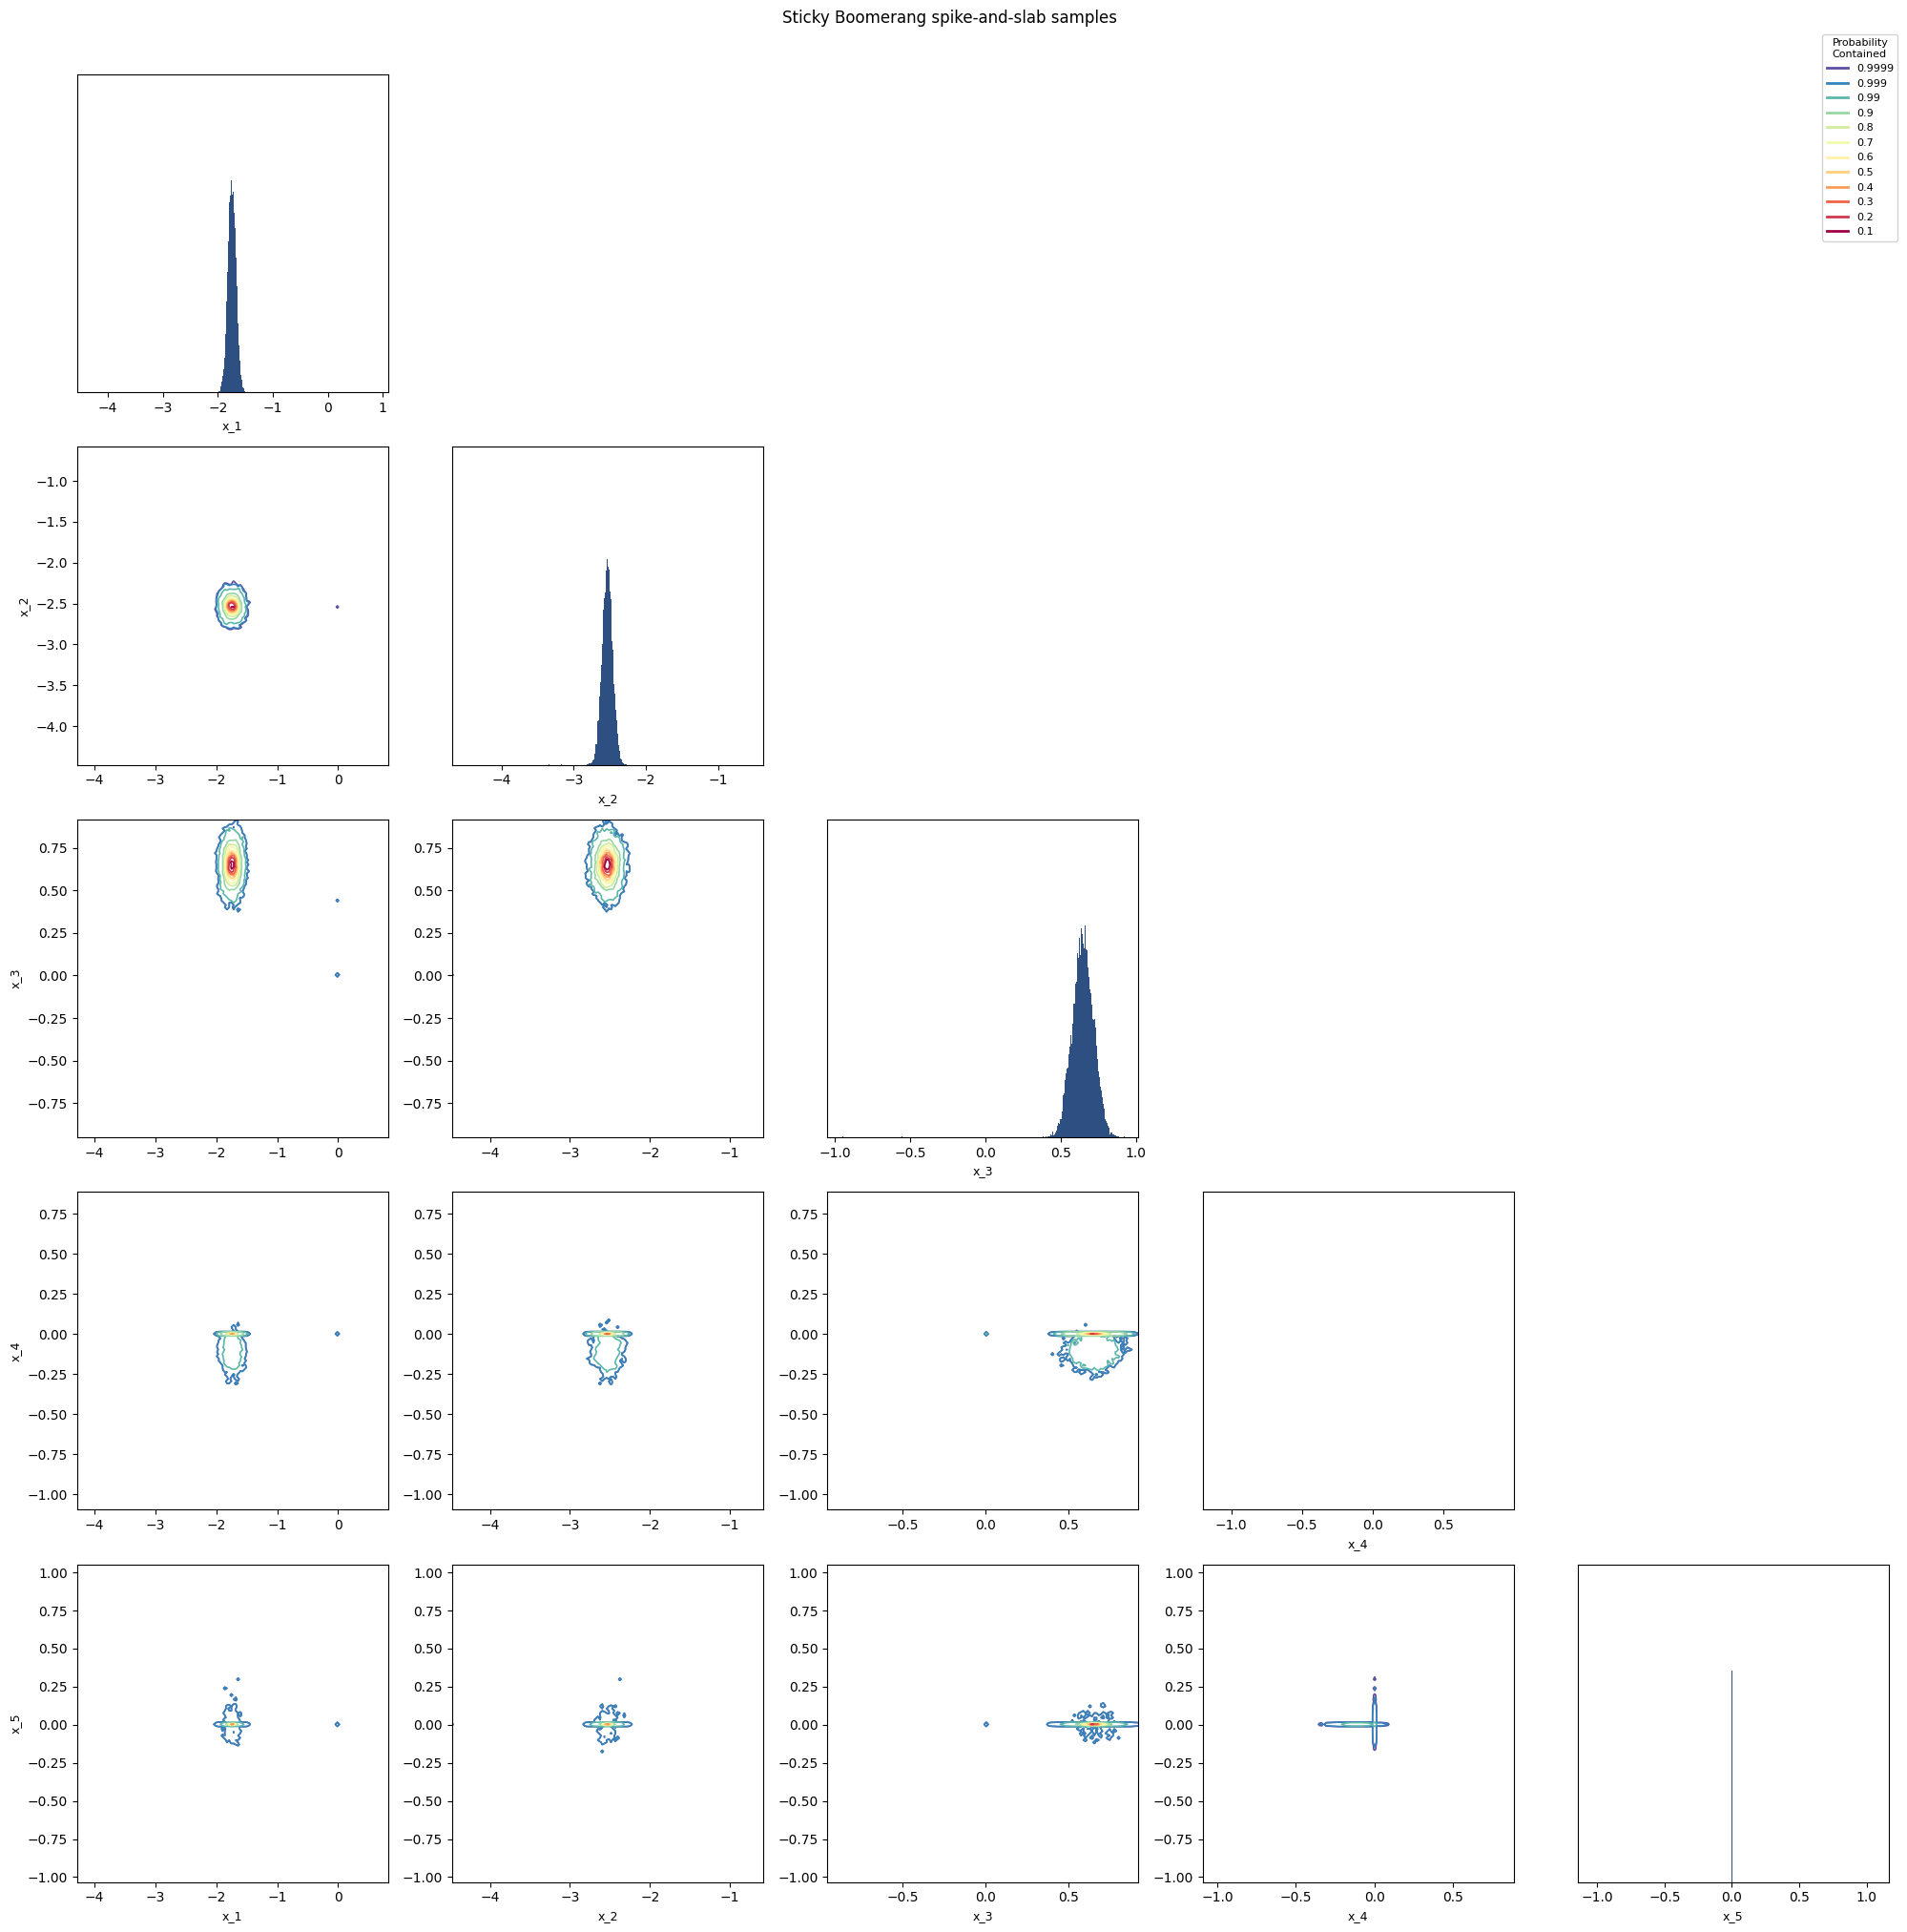

In [ ]:
# ── Plug in your own samples here ─────────────────────────────────────────────
variable_names_ss = ['x_1', 'x_2', 'x_3', 'x_4', 'x_5']   # optional

fig, axes = better_pairs(
    x_pli,
    resol=0.7,           # increase if contours are too jagged; decrease if over-smoothed
    labels=variable_names_ss,
    title='Sticky Boomerang spike-and-slab samples',
)
plt.show()

In [8]:
from matplotlib.gridspec import GridSpec

def plot_sticky_boomerang_general(sampler, beta_true=None, coord_names=None,
                                  max_trace_coords=10):
    """
    Parameters
    ----------
    sampler          : fitted StickyBoomerangSampler
    beta_true        : optional (p,) array of true coefficients
    coord_names      : optional list of str labels for each coordinate
    max_trace_coords : max number of coordinates to show in trace/ACF panels
    """
    p = sampler.D
    if coord_names is None:
        coord_names = [rf"$\beta_{{{j+1}}}$" for j in range(p)]

    # ── resample continuous path ──
    t, x = resample_sticky_pdmp_path(sampler)
    n_pts = len(t)

    # ── frozen statistics ──
    frozen_frac = np.array([np.mean(np.abs(x[:, d]) < 1e-10) for d in range(p)])
    # posterior inclusion probability = fraction of time NOT at zero
    pip = 1.0 - frozen_frac

    # ── model size over time (number of active coordinates) ──
    active_count = np.sum(np.abs(x) >= 1e-10, axis=1)

    # ── colour map for coordinates ──
    cmap = plt.cm.tab10 if p <= 10 else plt.cm.tab20
    colors = [cmap(i % cmap.N) for i in range(p)]

    # ── figure layout ──
    fig = plt.figure(figsize=(18, 10), constrained_layout=True)
    gs = GridSpec(2, 3, figure=fig)

    # ═══════════════════════════════════════════════════════════
    # Row 1, col 0 — Marginal box / violin plots
    # ═══════════════════════════════════════════════════════════
    ax1 = fig.add_subplot(gs[0, 0])
    # thin to at most 5000 points for the violin
    step = max(1, n_pts // 5000)
    data_thin = [x[::step, d] for d in range(p)]
    parts = ax1.violinplot(data_thin, positions=range(p), showmedians=True,
                           showextrema=False)
    for i, pc in enumerate(parts["bodies"]):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.5)
    if beta_true is not None:
        ax1.scatter(range(p), beta_true, marker="*", s=100, c="gold",
                    edgecolors="k", zorder=5, label=r"$\beta^*$")
        ax1.legend(fontsize=8)
    ax1.axhline(0, c="grey", lw=0.5, ls="--")
    ax1.set_xticks(range(p))
    ax1.set_xticklabels(coord_names, fontsize=8, rotation=45 if p > 6 else 0)
    ax1.set_ylabel("Value")
    ax1.set_title("Marginal distributions")

    # ═══════════════════════════════════════════════════════════
    # Row 1, col 1 — Posterior inclusion probabilities
    # ═══════════════════════════════════════════════════════════
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.bar(range(p), pip, color=colors, edgecolor="k", lw=0.5)
    ax2.axhline(0.5, c="grey", lw=0.8, ls="--", label="PIP = 0.5")
    ax2.set_xticks(range(p))
    ax2.set_xticklabels(coord_names, fontsize=8, rotation=45 if p > 6 else 0)
    ax2.set_ylabel("Inclusion probability")
    ax2.set_ylim(0, 1.05)
    ax2.set_title("Posterior inclusion P(β ≠ 0)")
    ax2.legend(fontsize=8)
    # annotate bars
    for i, v in enumerate(pip):
        ax2.text(i, v + 0.02, f"{v:.2f}", ha="center", fontsize=7)

    # ═══════════════════════════════════════════════════════════
    # Row 1, col 2 — Active model size over time
    # ═══════════════════════════════════════════════════════════
    ax3 = fig.add_subplot(gs[0, 2])
    # downsample for plotting
    step_t = max(1, n_pts // 3000)
    ax3.plot(t[::step_t], active_count[::step_t], lw=0.4, c="teal")
    ax3.set_xlabel("t")
    ax3.set_ylabel("# active coords")
    ax3.set_ylim(-0.5, p + 0.5)
    ax3.set_title("Model size over time")
    ax3.axhline(p, c="grey", lw=0.5, ls=":", label=f"full model (p={p})")
    if beta_true is not None:
        n_true_nonzero = np.sum(np.abs(beta_true) > 1e-10)
        ax3.axhline(n_true_nonzero, c="crimson", lw=0.8, ls="--",
                    label=f"true size = {n_true_nonzero}")
    ax3.legend(fontsize=8)

    # ═══════════════════════════════════════════════════════════
    # Row 2, col 0 — Trace plots (stacked)
    # ═══════════════════════════════════════════════════════════
    n_trace = min(p, max_trace_coords)
    ax4 = fig.add_subplot(gs[1, 0])
    for d in range(n_trace):
        ax4.plot(t[::step_t], x[::step_t, d], lw=0.3, c=colors[d],
                 label=coord_names[d], alpha=0.8)
    ax4.set_xlabel("t")
    ax4.set_ylabel("β")
    ax4.set_title(f"Traces (first {n_trace} coords)")
    ax4.legend(fontsize=6, ncol=min(n_trace, 5), loc="upper right")

    # ═══════════════════════════════════════════════════════════
    # Row 2, col 1 — Autocorrelation
    # ═══════════════════════════════════════════════════════════
    ax5 = fig.add_subplot(gs[1, 1])
    max_lag = min(300, n_pts // 2)
    for d in range(n_trace):
        series = x[:, d] - x[:, d].mean()
        acf = np.correlate(series, series, mode="full")
        acf = acf[len(acf) // 2:]
        acf /= acf[0] if acf[0] > 0 else 1.0
        ax5.plot(range(max_lag), acf[:max_lag], lw=0.7, c=colors[d],
                 label=coord_names[d], alpha=0.8)
    ax5.axhline(0, c="grey", lw=0.5, ls="--")
    ax5.set_xlabel("Lag")
    ax5.set_ylabel("ACF")
    ax5.set_title("Autocorrelation")
    ax5.legend(fontsize=6, ncol=min(n_trace, 5), loc="upper right")

    # ═══════════════════════════════════════════════════════════
    # Row 2, col 2 — Frozen-time bar chart
    # ═══════════════════════════════════════════════════════════
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.barh(range(p), frozen_frac, color=colors, edgecolor="k", lw=0.5)
    ax6.set_yticks(range(p))
    ax6.set_yticklabels(coord_names, fontsize=8)
    ax6.set_xlabel("Fraction of time frozen at 0")
    ax6.set_xlim(0, 1.05)
    ax6.set_title("Time spent frozen")
    ax6.invert_yaxis()
    # annotate
    for i, v in enumerate(frozen_frac):
        ax6.text(v + 0.02, i, f"{v:.1%}", va="center", fontsize=7)

    fig.suptitle(f"Sticky Boomerang — Logistic Regression (p = {p})",
                 fontsize=14, fontweight="bold")
    plt.show()
    #return fig
    

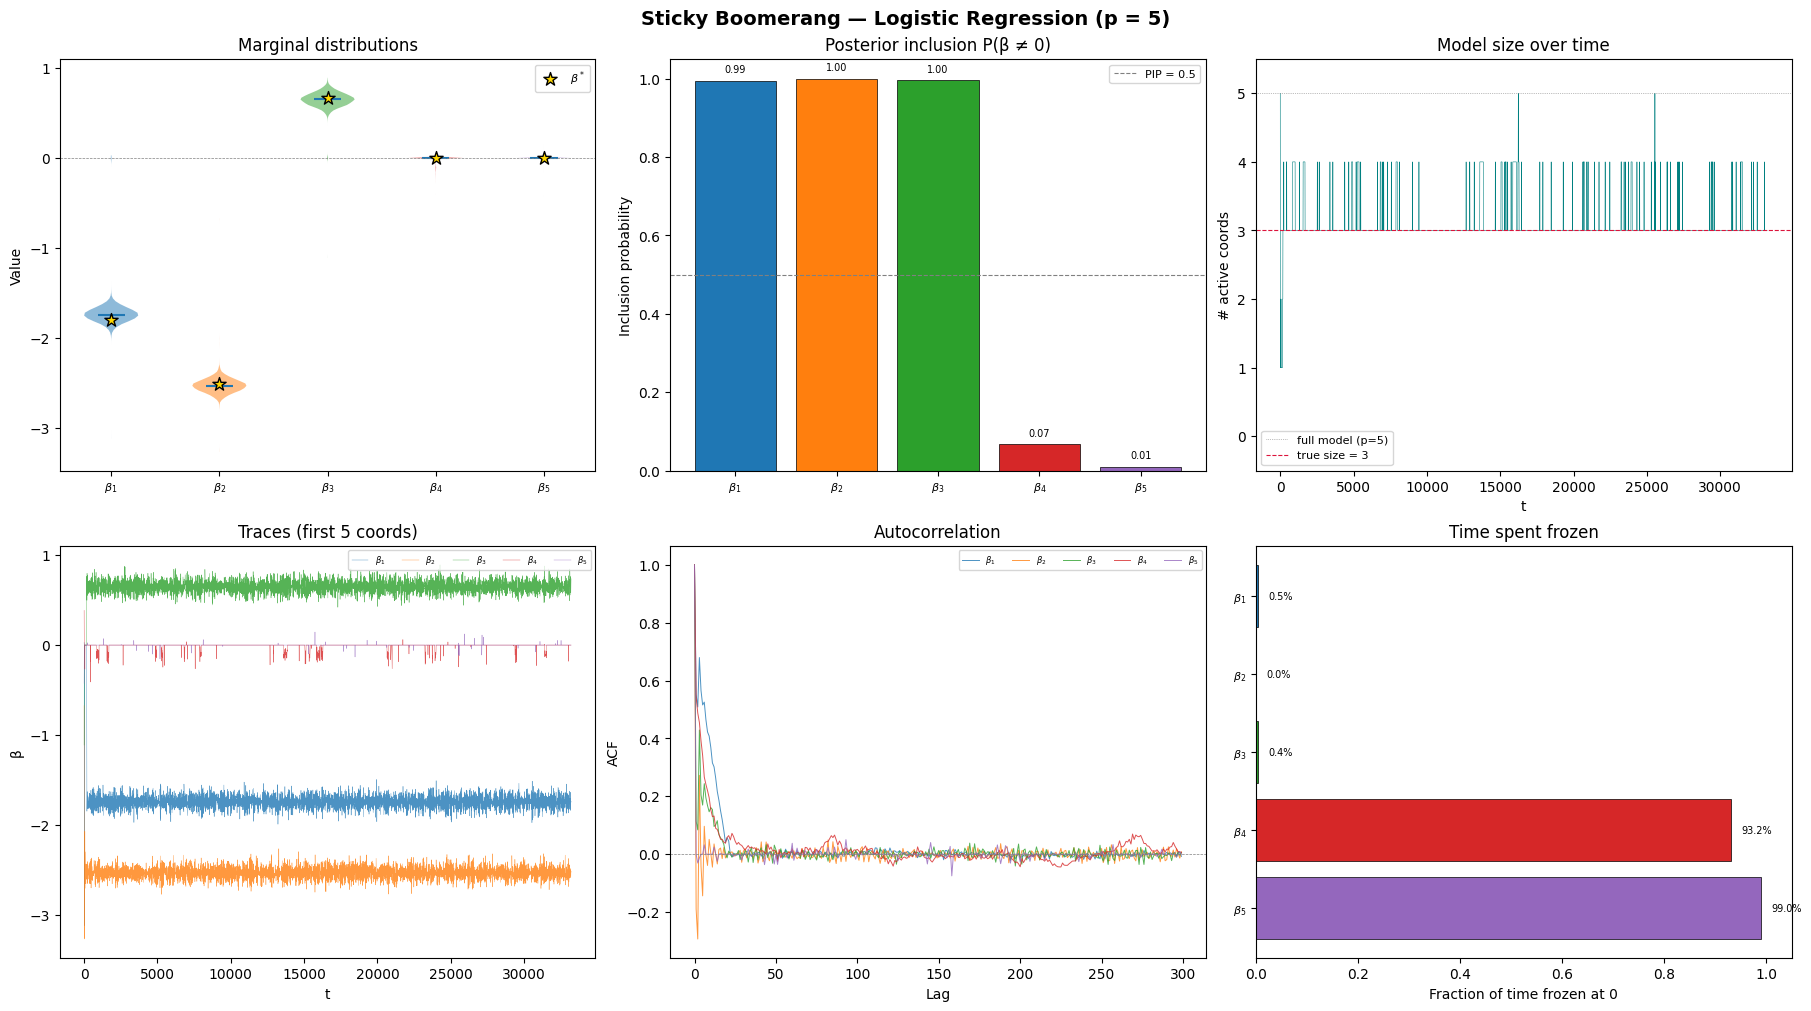

In [9]:
plot_sticky_boomerang_general(sampler, beta_true=theta_true)

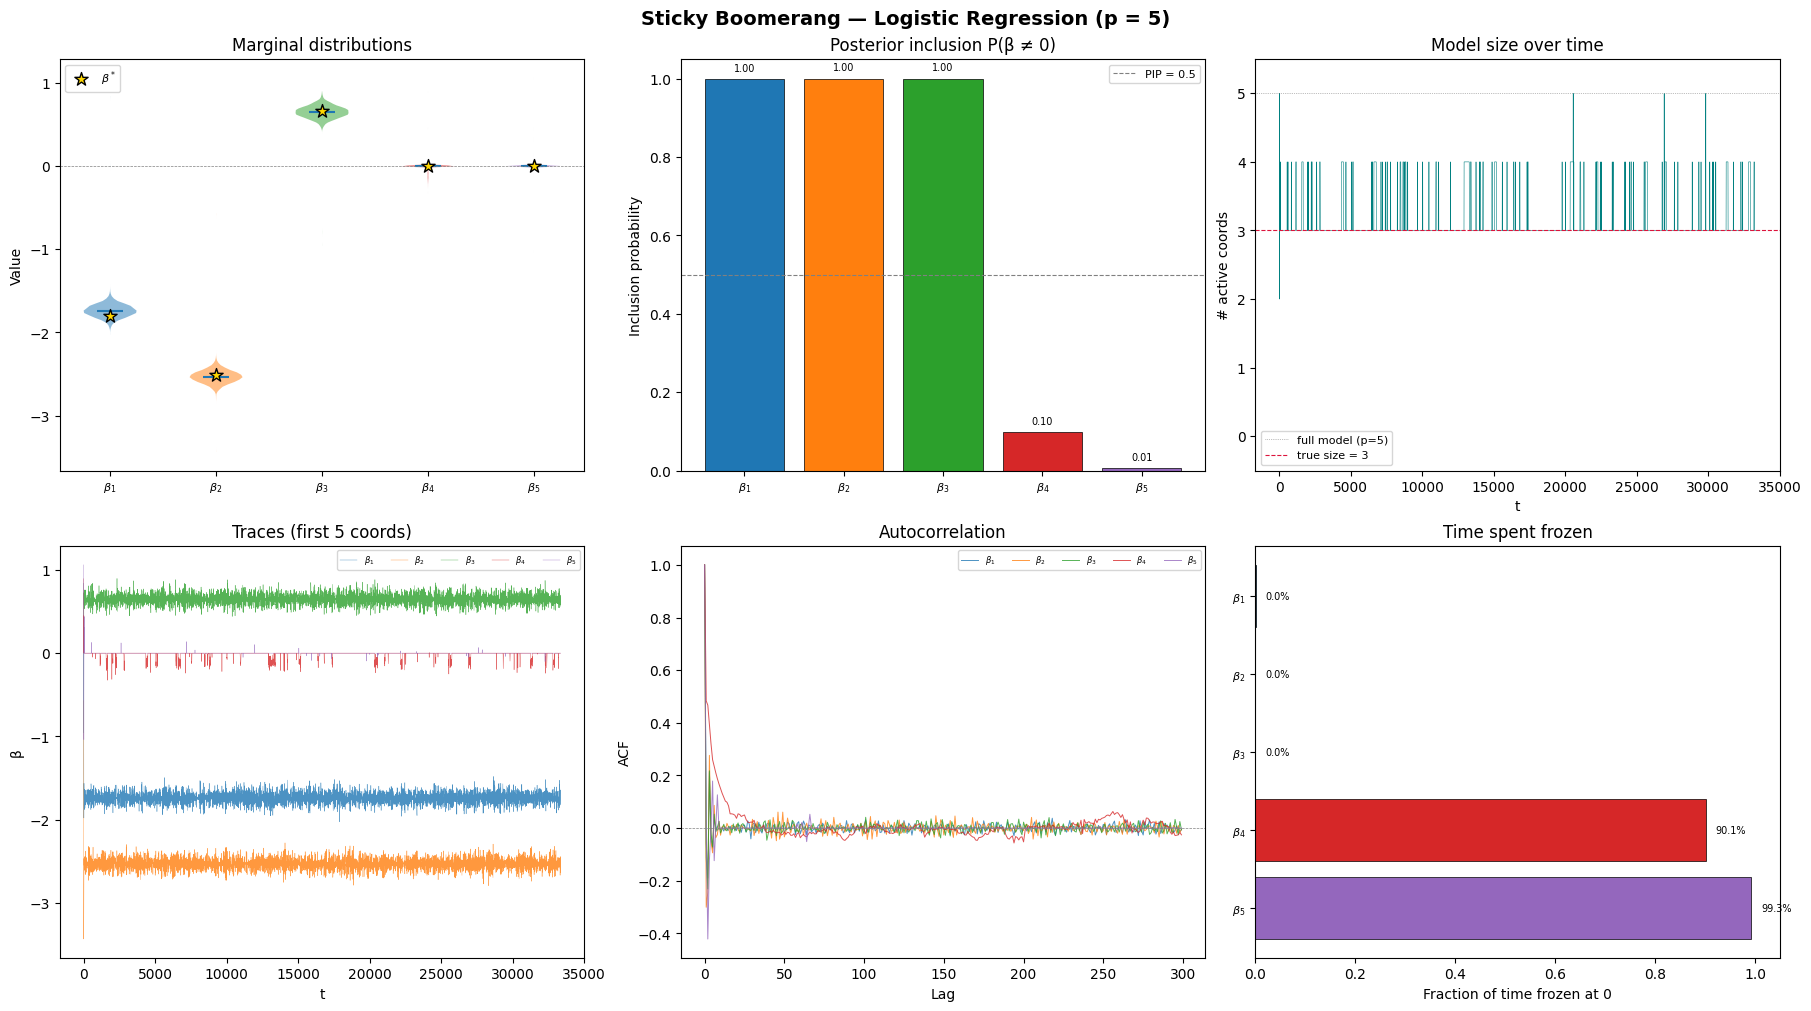

In [10]:
plot_sticky_boomerang_general(sampler_pli, beta_true=theta_true)

In [11]:
theta_true

array([-1.79953635, -2.51634498,  0.66523259,  0.        ,  0.        ])